In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/MU projekat/task1_dataset_modified.csv')

##KNN

In [3]:
# Pronalaženje kolona sa NaN vrijednostima
nan_columns = df.columns[df.isnull().any()].tolist()

print("Kolone s NaN vrijednostima:")
for col in nan_columns:
    print(f"{col}: {df[col].isnull().sum()} NaN vrijednosti")


Kolone s NaN vrijednostima:
Occupation: 6927 NaN vrijednosti
Amount_invested_monthly: 4409 NaN vrijednosti
Amount_invested_monthly_normalized: 4409 NaN vrijednosti


## KNN

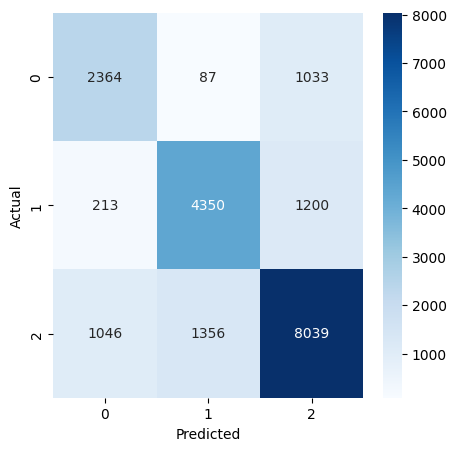

Klasifikacijski izvještaj:
              precision    recall  f1-score   support

        Good       0.65      0.68      0.67      3484
        Poor       0.75      0.75      0.75      5763
    Standard       0.78      0.77      0.78     10441

    accuracy                           0.75     19688
   macro avg       0.73      0.73      0.73     19688
weighted avg       0.75      0.75      0.75     19688

Kappa statistika: 0.59
Tačnost modela: 74.93%


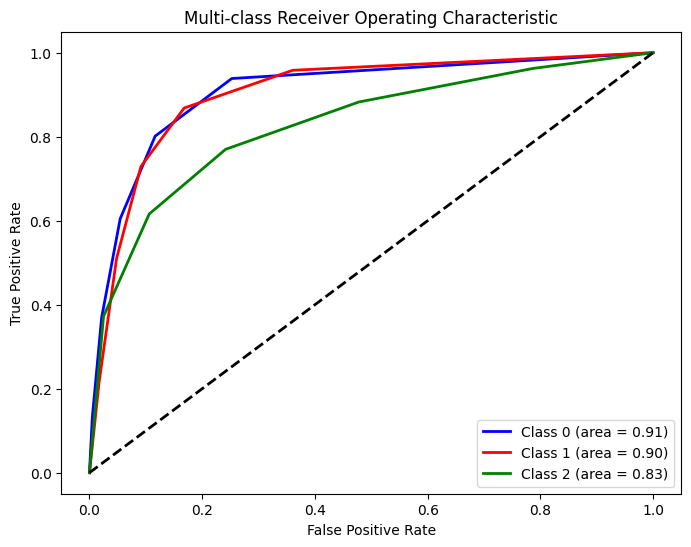

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, cohen_kappa_score, roc_curve, auc
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Učitavanje podataka
df = pd.read_csv('/content/drive/MyDrive/MU projekat/task1_dataset_modified.csv')

# Popunjavanje nedostajućih vrijednosti
month_mode = df['Month'].mode()[0]
df['Month'] = df['Month'].fillna(month_mode)

occupation_mode = df['Occupation'].mode()[0]
df['Occupation'] = df['Occupation'].fillna(occupation_mode)

median_value = df['Amount_invested_monthly_normalized'].median()
df['Amount_invested_monthly_normalized'] = df['Amount_invested_monthly_normalized'].fillna(median_value)

# Priprema podataka
X = df.drop('Credit_Score', axis=1)
X = X.drop('Amount_invested_monthly', axis=1)
y = df['Credit_Score']

numeric_features = X.select_dtypes(include=['float64', 'int64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# One hot encoding za kategoričke varijable i skaliranje za numeričke
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

knn = KNeighborsClassifier(n_neighbors=5)
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', knn)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

# Evaluacija modela
y_pred = pipeline.predict(X_test)
y_true = y_test

cm = confusion_matrix(y_true, y_pred)

f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Klasifikacijski izvještaj:")
print(classification_report(y_true, y_pred))

kappa = cohen_kappa_score(y_true, y_pred)
print(f'Kappa statistika: {kappa:.2f}')

accuracy = pipeline.score(X_test, y_test)
print(f'Tačnost modela: {accuracy * 100:.2f}%')


# Binarizacija labela za višeklasnu klasifikaciju
y_binarized = label_binarize(y_test, classes=['Good', 'Poor', 'Standard'])
n_classes = y_binarized.shape[1]

# Predikcija vjerovatnoća za svaku klasu
y_score = pipeline.predict_proba(X_test)

# Crtanje ROC krive za svaku klasu
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']
for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## KNN sa SMOTE

<ipython-input-9-ff8c5c3331f4>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Month'].fillna(df['Month'].mode()[0], inplace=True)
<ipython-input-9-ff8c5c3331f4>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

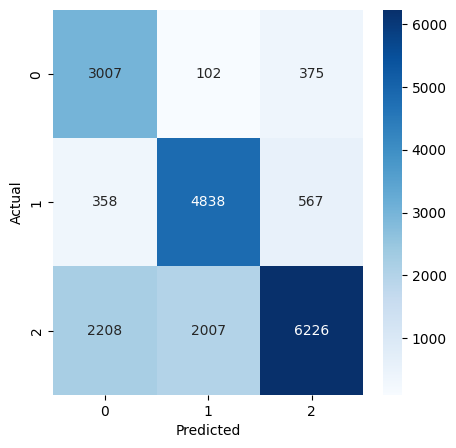


Izveštaj o klasifikaciji:
              precision    recall  f1-score   support

        Good       0.54      0.86      0.66      3484
        Poor       0.70      0.84      0.76      5763
    Standard       0.87      0.60      0.71     10441

    accuracy                           0.71     19688
   macro avg       0.70      0.77      0.71     19688
weighted avg       0.76      0.71      0.72     19688

Tačnost modela: 71.47%


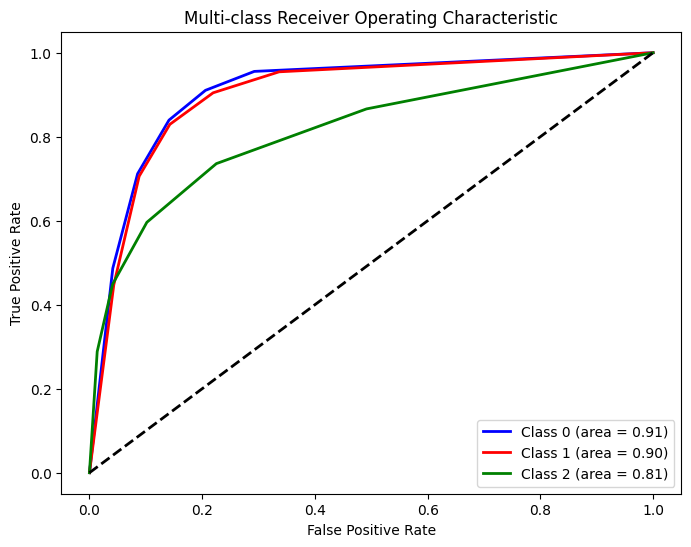

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/MU projekat/task1_dataset_modified.csv')

df['Month'].fillna(df['Month'].mode()[0], inplace=True)
df['Occupation'].fillna(df['Occupation'].mode()[0], inplace=True)
df['Amount_invested_monthly_normalized'].fillna(
    df['Amount_invested_monthly_normalized'].median(), inplace=True
)

X = df.drop(['Credit_Score', 'Amount_invested_monthly'], axis=1)
y = df['Credit_Score']

numeric_features = X.select_dtypes(include=['float64', 'int64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy='auto', random_state=42)),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nIzveštaj o klasifikaciji:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Tačnost modela: {accuracy * 100:.2f}%")


from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizacija labela za višeklasnu klasifikaciju
y_binarized = label_binarize(y_test, classes=['Good', 'Poor', 'Standard'])
n_classes = y_binarized.shape[1]

# Predikcija vjerovatnoća za svaku klasu
y_score = pipeline.predict_proba(X_test)

# Crtanje ROC krive za svaku klasu
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']
for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()



## Cross validation

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/MU projekat/task1_dataset_modified.csv')

df['Month'] = df['Month'].fillna(df['Month'].mode()[0])
df['Occupation'] = df['Occupation'].fillna(df['Occupation'].mode()[0])
df['Amount_invested_monthly_normalized'] = df['Amount_invested_monthly_normalized'].fillna(
    df['Amount_invested_monthly_normalized'].median()
)

X = df.drop(['Credit_Score', 'Amount_invested_monthly'], axis=1)
y = df['Credit_Score']

numeric_features = X.select_dtypes(include=['float64', 'int64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=kf, scoring='accuracy')


print(f'Prosječna tačnost: {scores.mean() * 100:.2f}%')



Prosječna tačnost: 75.65%


## Oversampling

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


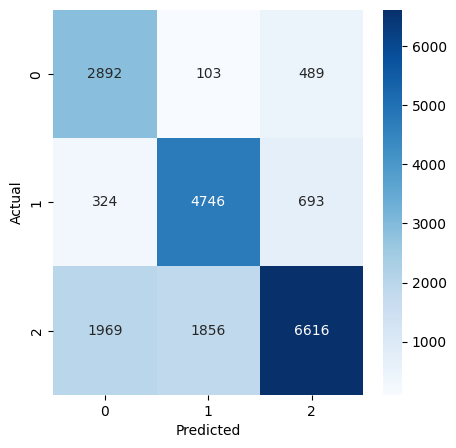

Klasifikacijski izvještaj:
              precision    recall  f1-score   support

        Good       0.56      0.83      0.67      3484
        Poor       0.71      0.82      0.76      5763
    Standard       0.85      0.63      0.73     10441

    accuracy                           0.72     19688
   macro avg       0.70      0.76      0.72     19688
weighted avg       0.76      0.72      0.73     19688

Kappa statistika: 0.57
Tačnost modela: 72.40%


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, cohen_kappa_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/MU projekat/task1_dataset_modified.csv')

month_mode = df['Month'].mode()[0]
df['Month'] = df['Month'].fillna(month_mode)

occupation_mode = df['Occupation'].mode()[0]
df['Occupation'] = df['Occupation'].fillna(occupation_mode)

median_value = df['Amount_invested_monthly_normalized'].median()
df['Amount_invested_monthly_normalized'] = df['Amount_invested_monthly_normalized'].fillna(median_value)

X = df.drop(['Credit_Score', 'Amount_invested_monthly'], axis=1)
y = df['Credit_Score']

numeric_features = X.select_dtypes(include=['float64', 'int64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

oversampler = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

knn = KNeighborsClassifier(n_neighbors=5)
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', knn)])

pipeline.fit(X_train_resampled, y_train_resampled)

y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Klasifikacijski izvještaj:")
print(classification_report(y_test, y_pred))

kappa = cohen_kappa_score(y_test, y_pred)
print(f'Kappa statistika: {kappa:.2f}')

accuracy = accuracy_score(y_test, y_pred)
print(f'Tačnost modela: {accuracy * 100:.2f}%')


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validatio

Prosječna tačnost: 72.36%
Standardna devijacija tačnosti: 0.44%


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



Izvještaj o klasifikaciji:

              precision    recall  f1-score   support

        Good       0.55      0.85      0.67      3511
        Poor       0.69      0.84      0.76      5704
    Standard       0.87      0.61      0.71     10473

    accuracy                           0.72     19688
   macro avg       0.70      0.77      0.71     19688
weighted avg       0.76      0.72      0.72     19688



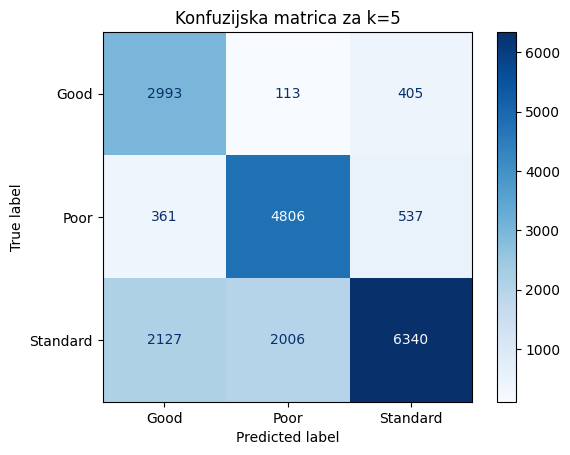

In [ ]:
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt


df = pd.read_csv('/content/drive/MyDrive/MU projekat/task1_dataset_modified.csv')

df['Month'] = df['Month'].fillna(df['Month'].mode()[0])
df['Occupation'] = df['Occupation'].fillna(df['Occupation'].mode()[0])
df['Amount_invested_monthly_normalized'] = df['Amount_invested_monthly_normalized'].fillna(
    df['Amount_invested_monthly_normalized'].median()
)

X = df.drop(['Credit_Score', 'Amount_invested_monthly'], axis=1)
y = df['Credit_Score']

numeric_features = X.select_dtypes(include=['float64', 'int64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

kf = KFold(n_splits=10, shuffle=True, random_state=42)

best_k = 5
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', KNeighborsClassifier(n_neighbors=best_k))
])

scores = cross_val_score(pipeline, X, y, cv=kf, scoring='accuracy')

print(f'Prosječna tačnost: {scores.mean() * 100:.2f}%')
print(f'Standardna devijacija tačnosti: {scores.std() * 100:.2f}%')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("\nIzvještaj o klasifikaciji:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=pipeline.named_steps['classifier'].classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.named_steps['classifier'].classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Konfuzijska matrica za k={best_k}')
plt.show()


<ipython-input-7-5d1fc286b015>:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Month'].fillna(df['Month'].mode()[0], inplace=True)
<ipython-input-7-5d1fc286b015>:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

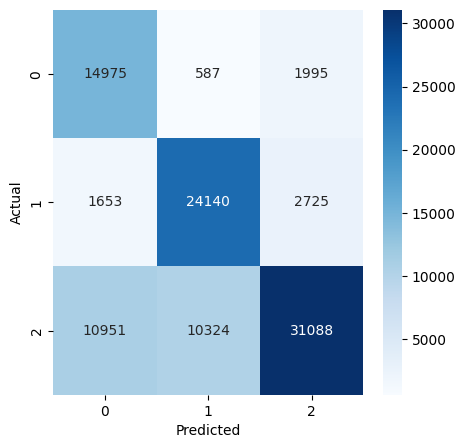


Izveštaj o klasifikaciji:
              precision    recall  f1-score   support

        Good       0.54      0.85      0.66     17557
        Poor       0.69      0.85      0.76     28518
    Standard       0.87      0.59      0.71     52363

    accuracy                           0.71     98438
   macro avg       0.70      0.76      0.71     98438
weighted avg       0.76      0.71      0.71     98438

Tačnost modela: 71.32%


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validatio


Tačnost u različitim foldovima cross-validation-a: [0.71281999 0.71921983 0.71038196 0.71204348 0.71138315]
Prosečna tačnost: 71.32%


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# Učitavanje podataka
df = pd.read_csv('/content/drive/MyDrive/MU projekat/task1_dataset_modified.csv')

# Obrada nedostajućih vrednosti
df['Month'].fillna(df['Month'].mode()[0], inplace=True)
df['Occupation'].fillna(df['Occupation'].mode()[0], inplace=True)
df['Amount_invested_monthly_normalized'].fillna(
    df['Amount_invested_monthly_normalized'].median(), inplace=True
)

# Definisanje X i y
X = df.drop(['Credit_Score', 'Amount_invested_monthly'], axis=1)
y = df['Credit_Score']

# Razdvajanje numeričkih i kategorizovanih atributa
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Preprocesor: standardizacija numeričkih vrednosti i one-hot encoding za kategorizovane
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

# Definisanje pipeline-a
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy='auto', random_state=42)),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Stratifikovani KFold za cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation: predikcija za svaki fold
y_pred = cross_val_predict(pipeline, X, y, cv=cv)

# Confusion matrix
cm = confusion_matrix(y, y_pred)

# Vizualizacija confusion matrix-a
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Izveštaj o klasifikaciji
print("\nIzveštaj o klasifikaciji:")
print(classification_report(y, y_pred))

# Tačnost modela
accuracy = accuracy_score(y, y_pred)
print(f"Tačnost modela: {accuracy * 100:.2f}%")

# Opcionalno: Prikazivanje cross-validation rezultata za tačnost
cross_val_accuracies = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
print(f"\nTačnost u različitim foldovima cross-validation-a: {cross_val_accuracies}")
print(f"Prosečna tačnost: {cross_val_accuracies.mean() * 100:.2f}%")
